In [1]:
pip install yfinance


     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---- ----------------------------------- 0.3/3.0 MB 7.2 MB/s eta 0:00:01
     ------------ --------------------------- 0.9/3.0 MB 11.5 MB/s eta 0:00:01
     ----------------- ---------------------- 1.3/3.0 MB 10.1 MB/s eta 0:00:01
     -------------------------- ------------- 1.9/3.0 MB 10.2 MB/s eta 0:00:01
     --------------------------------- ------ 2.5/3.0 MB 11.3 MB/s eta 0:00:01
     ---------------------------------------  2.9/3.0 MB 11.0 MB/s eta 0:00:01
     ---------------------------------------- 3.0/3.0 MB 10.4 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.

In [3]:
import yfinance as yf

In [4]:
tesla_data = yf.download('TSLA')

[*********************100%%**********************]  1 of 1 completed


In [5]:
tesla_data.reset_index(inplace=True)

In [6]:
print(tesla_data.head())

        Date      Open      High       Low     Close  Adj Close     Volume
0 2010-06-29  1.266667  1.666667  1.169333  1.592667   1.592667  281494500
1 2010-06-30  1.719333  2.028000  1.553333  1.588667   1.588667  257806500
2 2010-07-01  1.666667  1.728000  1.351333  1.464000   1.464000  123282000
3 2010-07-02  1.533333  1.540000  1.247333  1.280000   1.280000   77097000
4 2010-07-06  1.333333  1.333333  1.055333  1.074000   1.074000  103003500


In [51]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [52]:
url = 'https://companiesmarketcap.com/tesla/revenue/'

In [53]:
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')

In [54]:
table = soup.find('table', {'class': 'table'})

In [55]:
quarters = []
revenues = []

In [56]:
for row in table.find_all('tr'):
    cols = row.find_all('td')
    if len(cols) > 0:
        quarters.append(cols[0].text.strip())
        revenues.append(cols[1].text.strip())

In [57]:
tesla_revenue_data = pd.DataFrame({
    'Quarter': quarters,
    'Revenue': revenues
})

In [58]:
print(tesla_revenue_data.tail())

   Quarter  Revenue
10    2013  $2.01 B
11    2012  $0.41 B
12    2011  $0.20 B
13    2010  $0.11 B
14    2009  $0.11 B


In [59]:
import yfinance as yf
import pandas as pd

In [60]:
gme_data = yf.download('GME', start='2010-01-01', end='2021-12-31')

[*********************100%%**********************]  1 of 1 completed


In [61]:
gme_data.reset_index(inplace=True)

In [62]:
gme_data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-01-04,5.5175,5.7375,5.5000,5.7250,3.854644,26702800
1,2010-01-05,5.7275,5.9350,5.7250,5.8800,3.959005,21269600
2,2010-01-06,5.8650,6.0250,5.8050,6.0075,4.044851,21471200
3,2010-01-07,5.0025,5.2925,4.8550,5.1150,3.443929,164761200
4,2010-01-08,5.1600,5.3075,5.0575,5.0725,3.415315,47872400


In [105]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = 'https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue'
html_data = requests.get(url).text

soup = BeautifulSoup(html_data, 'html.parser')

tables = soup.find_all('table')
for table in tables:
    if 'GameStop Quarterly Revenue' in str(table):
        break

dates = []
revenues = []

for row in table.find_all('tr')[1:]:
    cols = row.find_all('td')
    dates.append(cols[0].text)
    revenues.append(cols[1].text.replace('$', '').replace(',', '').strip())

gme_revenue = pd.DataFrame({
    'Date': dates,
    'Revenue': revenues
})

gme_revenue.tail()

,Date,Revenue
10,2013,2.01 B
11,2012,0.41 B
12,2011,0.20 B
13,2010,0.11 B
14,2009,0.11 B


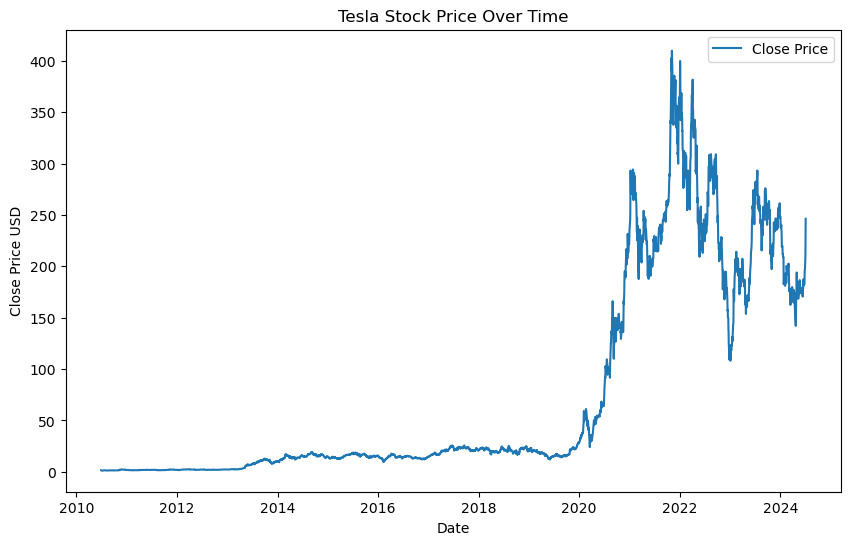

In [107]:
import matplotlib.pyplot as plt

def make_graph(data, title):
    plt.figure(figsize=(10, 6))
    plt.plot(data['Date'], data['Close'], label='Close Price')
    plt.xlabel('Date')
    plt.ylabel('Close Price USD')
    plt.title(title)
    plt.legend()
    plt.show()

tesla_data.sort_values('Date', inplace=True)

make_graph(tesla_data, 'Tesla Stock Price Over Time')

In [108]:
pip install matplotlib pandas beautifulsoup4 requests

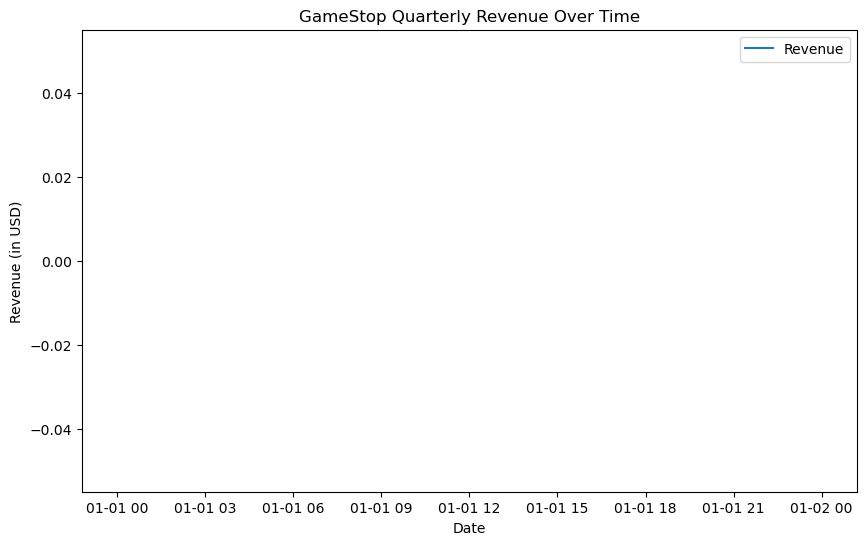

In [115]:
import matplotlib.pyplot as plt
import pandas as pd
from bs4 import BeautifulSoup
import requests
def make_graph(data, title):
    plt.figure(figsize=(10, 6))
    plt.plot(data['Date'], data['Revenue'], label='Revenue')
    plt.xlabel('Date')
    plt.ylabel('Revenue (in USD)')
    plt.title(title)
    plt.legend()
    plt.show()
url = 'https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue'
html_data = requests.get(url).text
soup = BeautifulSoup(html_data, 'html.parser')
tables = soup.find_all('table')
for table in tables:
    if 'GameStop Quarterly Revenue' in str(table):
        break
dates = []
revenues = []
for row in table.find_all('tr')[1:]:
    cols = row.find_all('td')
    dates.append(cols[0].text.strip())
    revenues.append(cols[1].text.replace('$', '').replace(',', '').strip())
gme_revenue = pd.DataFrame({
    'Date': dates,
    'Revenue': revenues
})
gme_revenue = gme_revenue[~gme_revenue['Date'].str.contains('TTM')]
gme_revenue['Revenue'] = pd.to_numeric(gme_revenue['Revenue'], errors='coerce')
def parse_dates(date):
    for fmt in ('%Y-%m-%d', '%Y-%m', '%Y'):
        try:
            return pd.to_datetime(date, format=fmt)
        except ValueError:
            continue
    return pd.NaT
gme_revenue['Date'] = gme_revenue['Date'].apply(parse_dates)
gme_revenue.dropna(subset=['Date'], inplace=True)
gme_revenue.sort_values('Date', inplace=True)
make_graph(gme_revenue, 'GameStop Quarterly Revenue Over Time')
